# --- Plot Rg vs Time, one figure per temperature ---

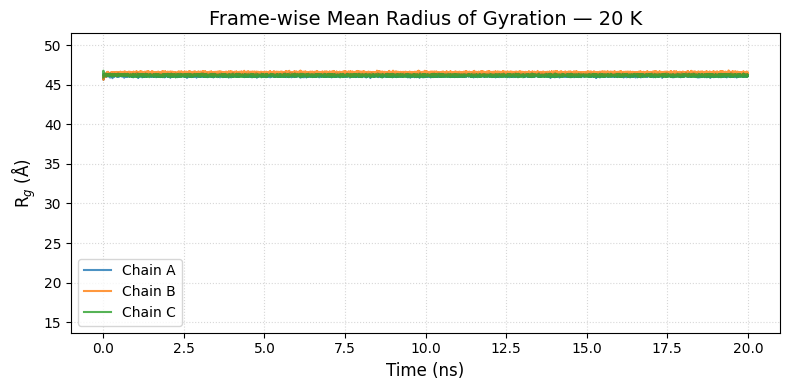

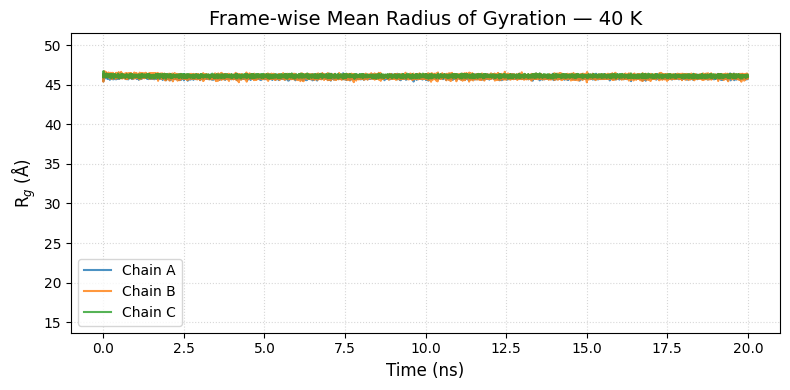

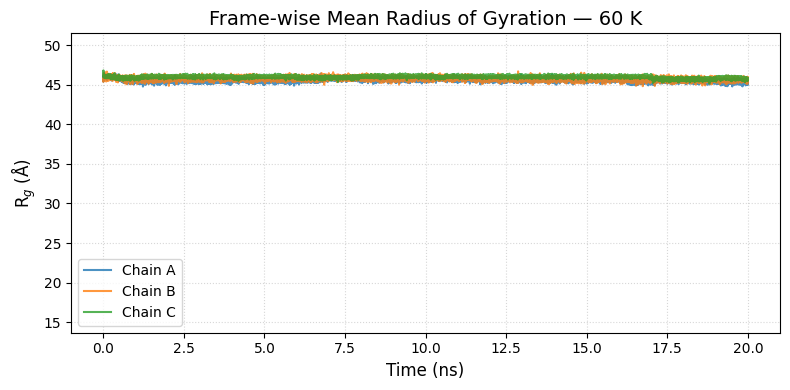

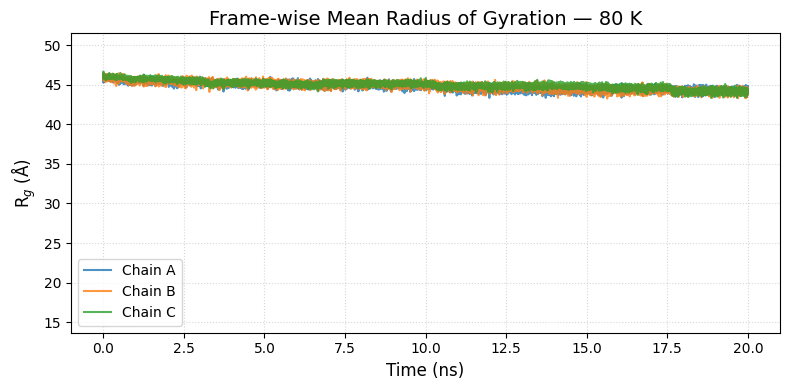

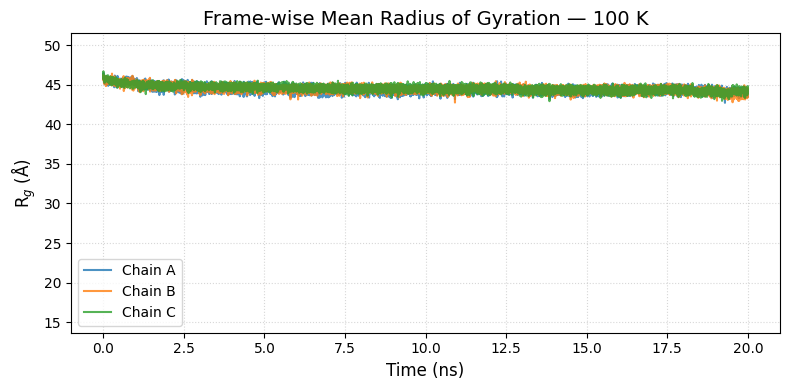

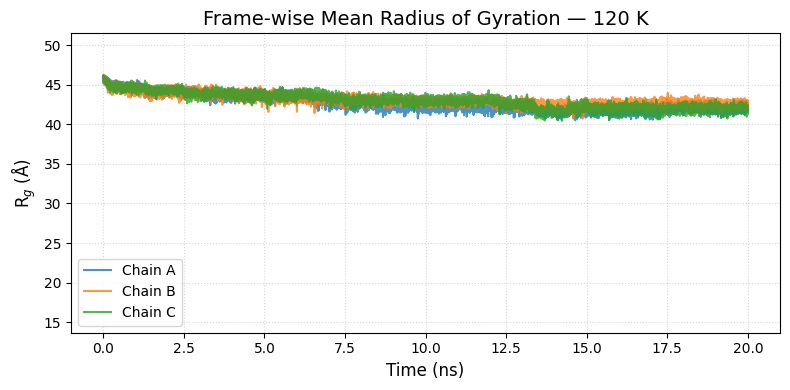

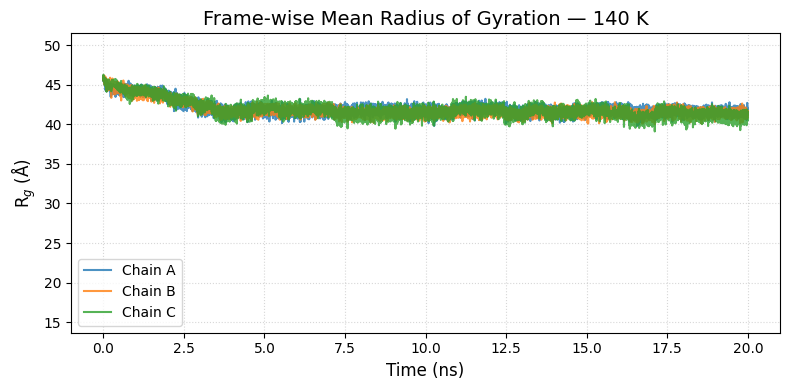

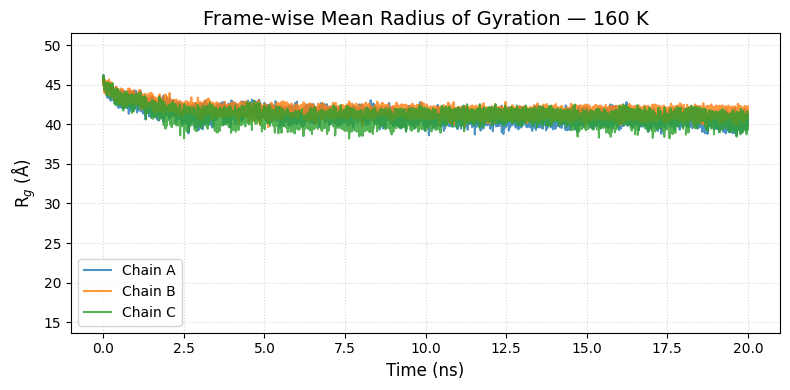

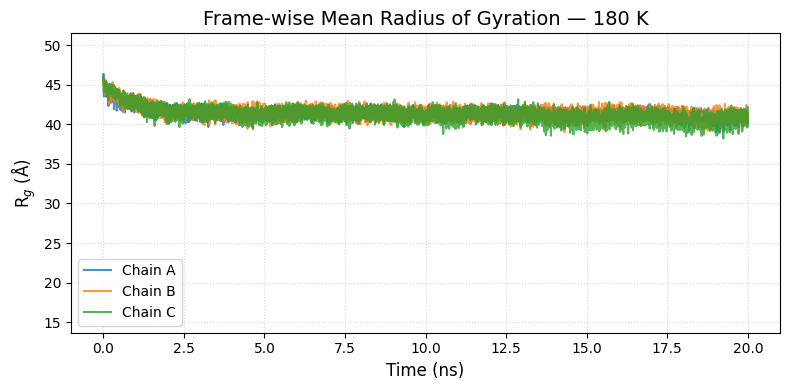

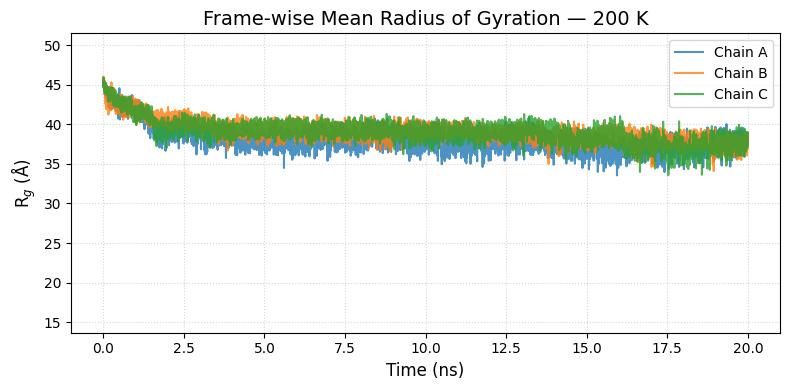

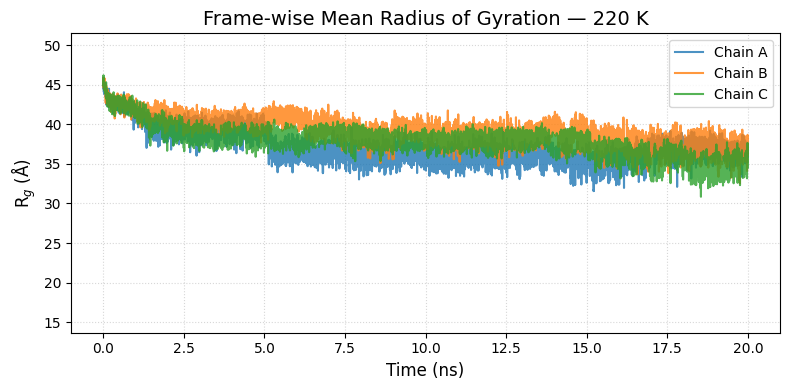

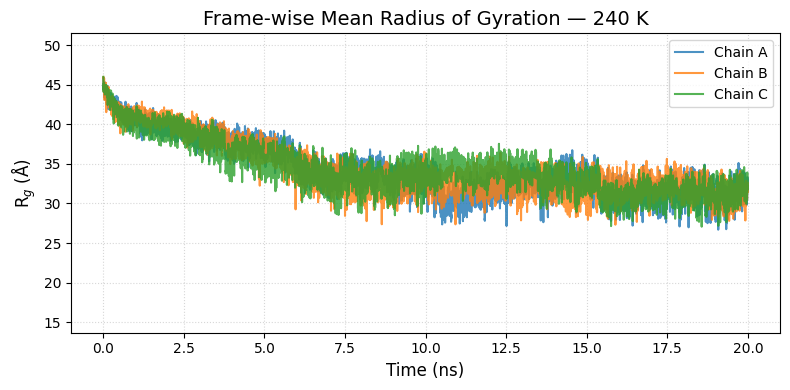

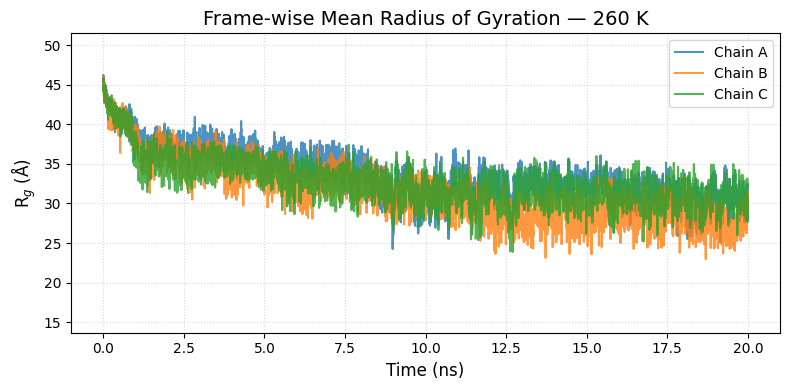

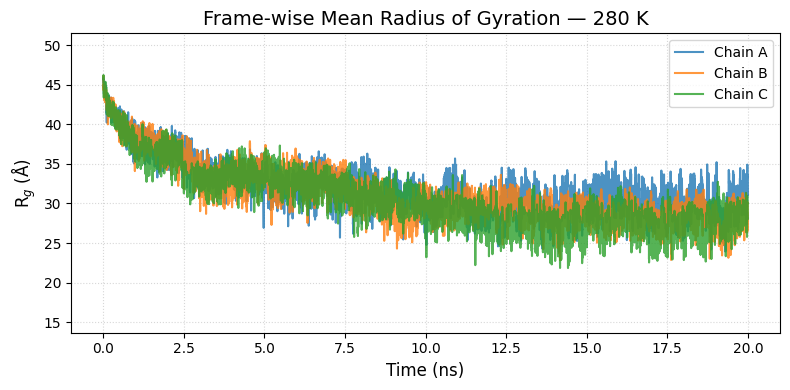

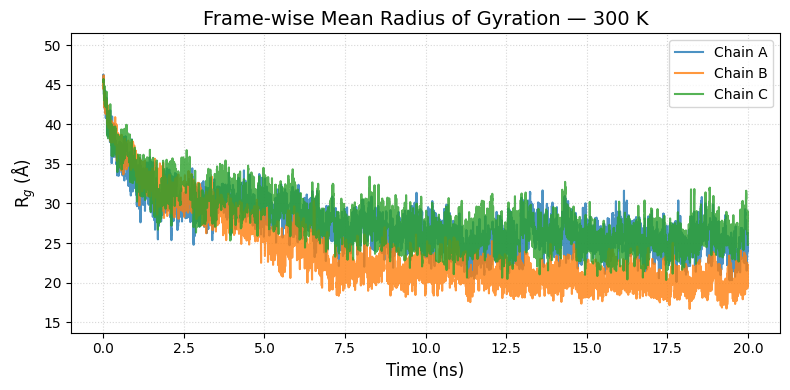

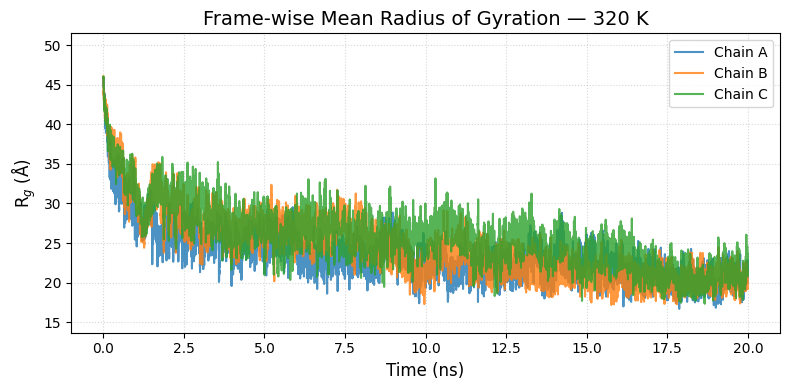

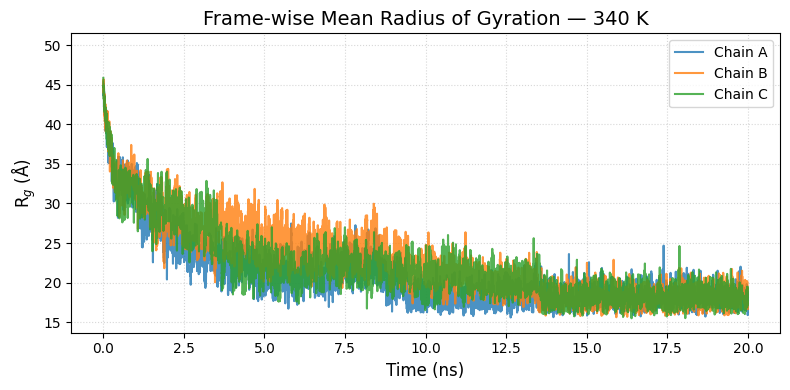

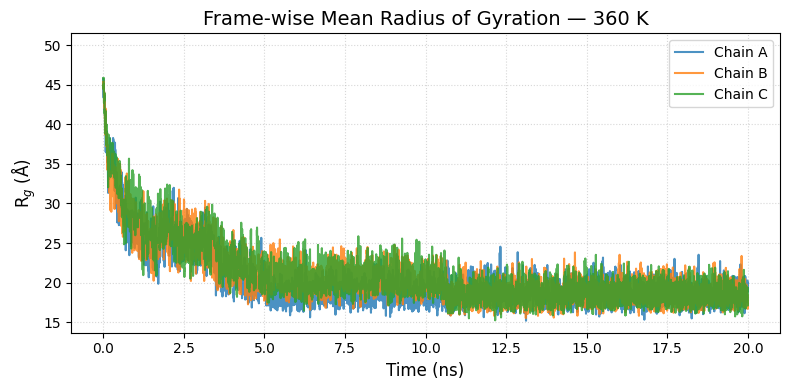

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─── Simulation timing ─────────────────────────────────────────────────────────
dt_ps           = 0.001546        # ps per integration step
report_interval = 1000            # steps between frames
frame_dt_ns     = report_interval * dt_ps / 1000.0  # ns per saved frame

# ─── Load your aggregated CSV ─────────────────────────────────────────────────
# (adjust filename if yours differs)
df = pd.read_csv('POG12_replicas_framewise_meanRg.csv')

chains = ['A','B','C']
colors = ['tab:blue','tab:orange','tab:green']

# ─── Plot per‐temperature ───────────────────────────────────────────────────────
for temp in sorted(df['Temperature (K)'].unique()):
    df_t = df[df['Temperature (K)'] == temp]
    n_frames = int(df_t['Frame'].max()) + 1
    time_ns = np.arange(n_frames) * frame_dt_ns

    fig, ax = plt.subplots(figsize=(8, 4))
    for chain, color in zip(chains, colors):
        y = df_t.loc[df_t['Chain'] == chain, 'Mean Rg (Å)'].values
        ax.plot(time_ns, y, label=f'Chain {chain}', color=color, alpha=0.8)

    ax.set_title(f'Frame‐wise Mean Radius of Gyration — {temp} K', fontsize=14)
    ax.set_xlabel('Time (ns)', fontsize=12)
    ax.set_ylabel('R$_g$ (Å)', fontsize=12)
    ax.set_ylim(df['Mean Rg (Å)'].min() * 0.9, df['Mean Rg (Å)'].max() * 1.1)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()


# --- Plot Rg vs Time, 3 plots per line ---

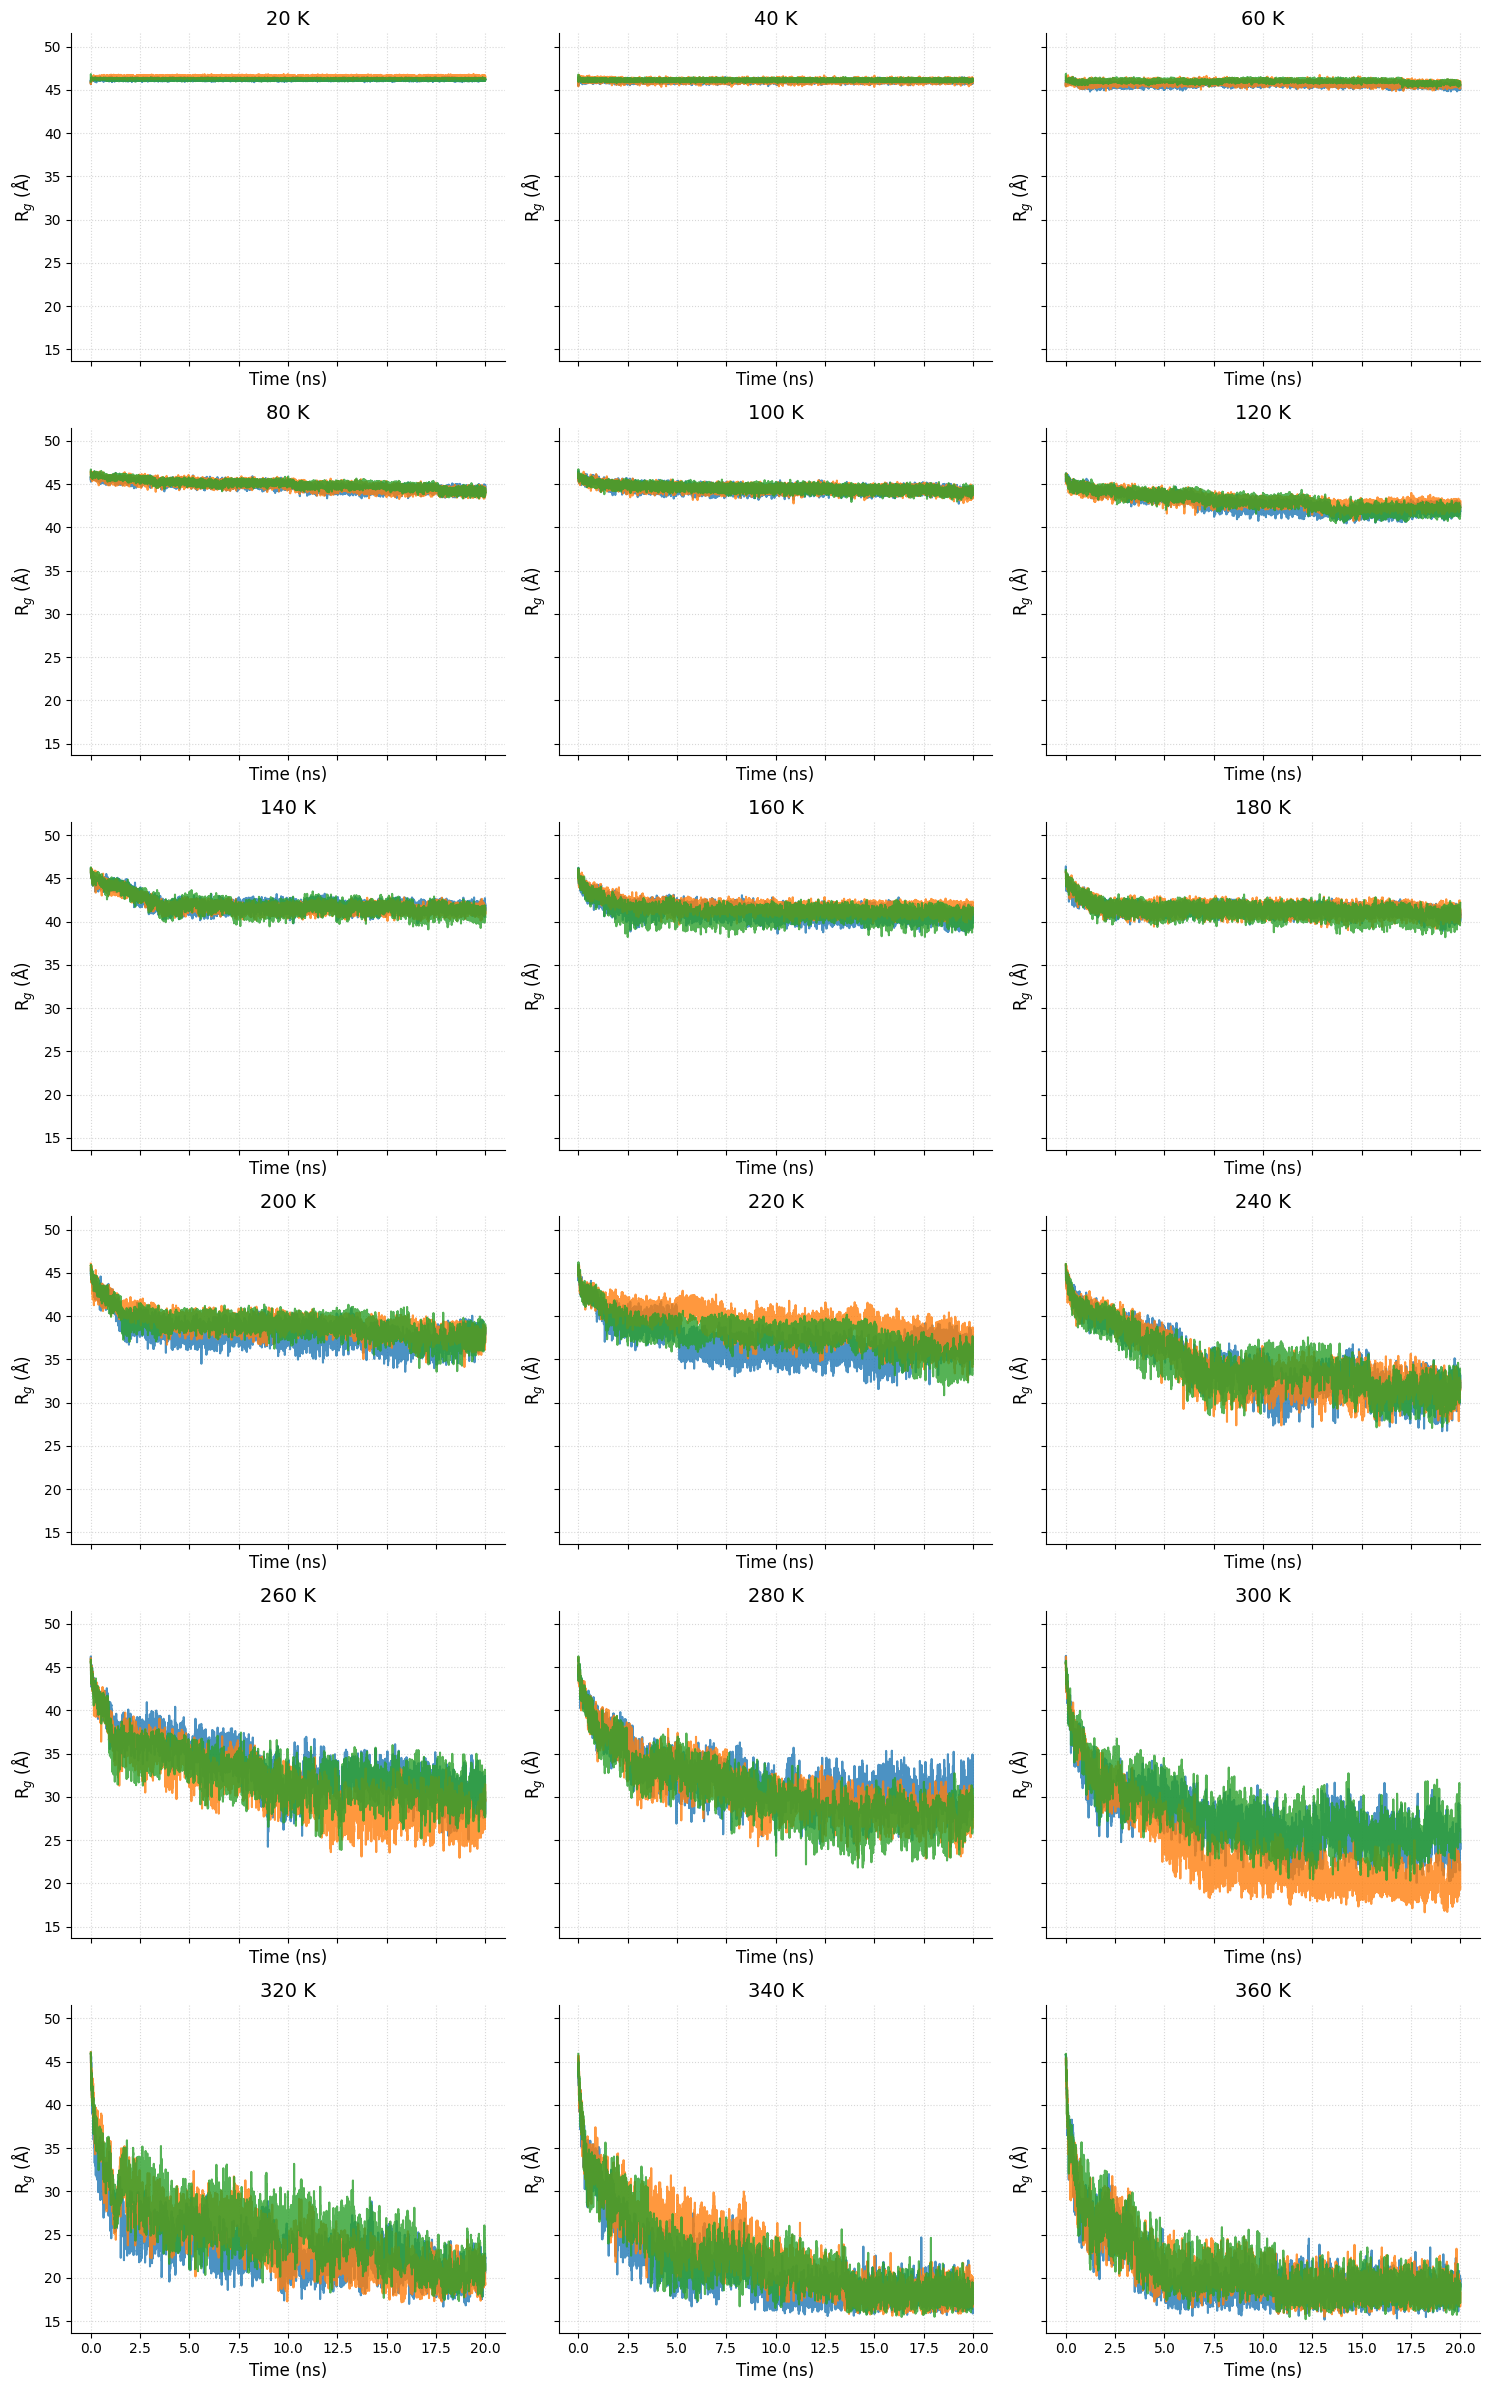

In [4]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─── Simulation timing ─────────────────────────────────────────────────────────
dt_ps           = 0.001546       # ps per integration step
report_interval = 1000           # steps between frames
frame_dt_ns     = report_interval * dt_ps / 1000.0  # ns per saved frame

# ─── Load the frame-wise mean‑Rg CSV ────────────────────────────────────────────
df = pd.read_csv('POG12_replicas_framewise_meanRg.csv')

chains = ['A','B','C']
colors = ['tab:blue','tab:orange','tab:green']

# ─── Prepare subplot grid ──────────────────────────────────────────────────────
temps   = sorted(df['Temperature (K)'].unique())
n_temps = len(temps)
n_cols  = 3
n_rows  = math.ceil(n_temps / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), sharex=True, sharey=True)
axes = axes.flatten()

# ─── Plot each temperature in its own subplot ─────────────────────────────────
for idx, temp in enumerate(temps):
    ax = axes[idx]
    df_t = df[df['Temperature (K)'] == temp]
    n_frames = int(df_t['Frame'].max()) + 1
    time_ns  = np.arange(n_frames) * frame_dt_ns

    for chain, color in zip(chains, colors):
        y = df_t.loc[df_t['Chain'] == chain, 'Mean Rg (Å)'].values
        ax.plot(time_ns, y, label=f'Chain {chain}', color=color, alpha=0.8)

    ax.set_title(f'{temp} K', fontsize=14)
    ax.set_xlabel('Time (ns)', fontsize=12)
    ax.set_ylabel('R$_g$ (Å)', fontsize=12)
    ax.set_ylim(df['Mean Rg (Å)'].min() * 0.9, df['Mean Rg (Å)'].max() * 1.1)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ─── Turn off any unused subplots ───────────────────────────────────────────────
for j in range(n_temps, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
